# Evaluating multimodal GRNs

Evaluating a multimodal gene regulatory network (GRN) requires two ingredients: a multiome dataset, comprising paired single-nucleus RNA-seq and ATAC-seq measurements, and a GRN inferred from that dataset. Together, these allow systematic assessment of whether the inferred regulatory relationships are supported by independent lines of evidence.

<div align="center">
  <img src="../_static/images/eval_n_dts.png" width="75%">
</div>

`gretapy` organizes evaluation into four complementary metric categories:

- **Genomic**: assesses whether GRN elements (TF binding sites, CREs, CRE-to-gene links) are supported by genome-wide measurements.
- **Predictive**: tests whether the GRN topology can predict molecular readouts, such as gene expression from TF activity or the presence of active gene sets.
- **Literature**: checks whether the TFs, TF-TF interactions, and TF-gene pairs in the GRN are supported by curated, experimentally validated evidence from the scientific literature.
- **Mechanistic**: evaluates whether the GRN can reproduce functional outcomes, including TF activity in perturbation experiments, gene expression changes after TF knockouts, and cell-type-specific steady states.

To support evaluation out of the box, `gretapy` provides 12 already-processed multimodal datasets spanning diverse human and mouse tissues and cell types. Each metric category can draw from multiple independent databases (e.g. ChIP-Atlas, ReMap2022, and UniBind for TF binding) or involve multiple subtasks (e.g. gene expression and chromatin accessibility prediction within the Omics metric), resulting in 25 distinct evaluation tasks across datasets. This multi-task design ensures that strong performance reflects consistency across diverse and orthogonal criteria, offering a robust and holistic view of GRN quality.

For each evaluation task, performance is quantified by defining true positives (TP), false positives (FP), and false negatives (FN) (**Table 1**). Precision and recall are then computed and summarized into an $F_{0.1}$ score, which weights precision ten times more than recall (β = 0.1), reflecting the principle that in GRN evaluation, predicting a small set of high-confidence edges is more informative than recovering many noisy ones.

<div align="center">
  <img src="../_static/images/f01.png" width="50%">
</div>

**Table 1.** Definition of evaluation tasks. TP: true positive; FP: false positive; FN: false negative.

| Category | Task | TP | FP | FN |
|---|---|---|---|---|
| Genomic | TF Binding | TF-CRE in GRN and in binding collection | TF-CRE in GRN but not in collection | TF-CRE not in GRN but in collection |
| Genomic | CREs | CRE in GRN and in annotation | CRE in GRN but not in annotation | CRE not in GRN but in annotation |
| Genomic | CRE to Gene | CRE-Gene in GRN and in annotation | CRE-Gene in GRN but not in annotation | CRE-Gene not in GRN but in annotation |
| Predictive | Omics | Omic feature in GRN with significant predicted–observed correlation | Omic feature in GRN with insignificant correlation | Omic feature not in GRN but in dataset |
| Predictive | Gene Sets | Gene set in GRN and predicted present in omics data | Gene set in GRN but not in omics data | Gene set not in GRN but in omics data |
| Literature | TF Markers | TF in GRN and in marker collection | TF in GRN but not in collection | TF not in GRN but in collection |
| Literature | TF Pairs | TF-TF in GRN and in interactions collection | TF-TF in GRN but not in collection | TF-TF not in GRN but in collection |
| Literature | Reference GRN | TF-Gene in GRN and in reference collection | TF-Gene in GRN but not in collection | TF-Gene not in GRN but in collection |
| Mechanistic | TF Scoring | TF in GRN with significant activity score for perturbation | TF in GRN with insignificant activity score | TF not in GRN but in perturbation experiment |
| Mechanistic | Perturbation Forecasting | TF targets in GRN with significant predicted–observed correlation | TF targets in GRN with insignificant correlation | TF not in GRN but in perturbation experiment |
| Mechanistic | Steady State Simulation | Steady state matching one cell type | Steady state matching multiple or no cell types | Cell type not generated but present in dataset |

Several evaluation tasks are made context-specific by filtering their reference databases using tissue- or cell-type-relevant terms. For example, when evaluating a dataset derived from heart tissue, only TF binding peaks annotated to cardiac cell types are retained; similarly, for brain datasets, only neuronal and glial annotations are used. This filtering ensures that evaluation reflects whether methods recover regulatory interactions relevant to the biological system under study, rather than generic genome-wide associations.

In this vignette, we begin by evaluating a toy GRN against a toy multiome dataset designed to simulate a PBMC-like tissue comprising B cells, T cells, and monocytes, with TF-gene interactions and marker genes grounded in prior biological knowledge. We walk through individual evaluation metrics step by step. We then demonstrate how to run the full benchmark across all 12 datasets and 25 tasks, and how to visualize and compare results against the precomputed scores of the 20 methods evaluated in the original GRETA manuscript.


## On a single dataset

Let's start by importing the toy dataset, which contains a multiome dataset as a MuData object, and a GRN that has been "inferred" from this data as a pandas dataframe.

<div class="alert alert-info">
    
**Note**

It is a requirement that features in the GRN, like CREs and Genes, are available as features in the multiome dataset, else it will throw an error.

</div>

In [1]:
import gretapy as gt
import pandas as pd

mdata, grn = gt.ds.toy()

In [2]:
mdata

MuData object with n_obs × n_vars = 60 × 93
  obs:	'celltype'
  2 modalities
    rna:	60 x 30
    atac:	60 x 63

In [3]:
grn.head()

,source,cre,target,score
0,PAX5,chr16-28926950-28927450,CD19,0.85
1,PAX5,chr16-28936000-28936500,CD19,0.72
2,PAX5,chr11-60443809-60444309,MS4A1,0.78
3,PAX5,chr19-41827233-41827733,CD79A,0.72
4,PAX5,chr18-63073346-63073846,BCL2,0.68


For this vignette, we use the toy dataset to keep computations fast. In practice, `gretapy` provides 12 pre-processed multiome datasets spanning diverse human and mouse tissues and cell types, which can be listed with `gt.show_datasets()`.

In [4]:
gt.show_datasets()

,organism,name,pubmed,geo
0,hg38,Brain,38491288,GSE193688
1,hg38,Breast,39122969,None
2,hg38,Embryo,37369347,GSE218314
3,hg38,Eye,36277849,GSE196235
4,hg38,Heart,37438528,None
5,hg38,Kidney,37333123,None
6,hg38,Lung,39266564,GSE241468
7,hg38,PBMC,None,None
8,hg38,Pituitary,35263594,GSE178454
9,hg38,Repr. Fibroblasts,37873116,GSE242419


These can then be easily downloaded with `gt.ds.read_dts`, for example:

```python
mdata = gt.ds.read_dts(organism='hg38', dts_name='PBMC')
```

<div class="alert alert-info">
    
**Note**

Any data `gretapy` downloads, it will be available at `./gretapy_data`

</div>

Next, we check which metrics are available for the given organism:

In [5]:
metrics = gt.show_metrics(organism="hg38")
metrics

,category,metric,db
0,Genomic,CRE to Gene,eQTL Catalogue
1,Genomic,CREs,ENCODE Blacklist
2,Genomic,CREs,ENCODE CREs
3,Genomic,CREs,GWAS Catalog
4,Genomic,CREs,Promoters
5,Genomic,CREs,Zhang21
6,Genomic,CREs,phastCons
7,Genomic,TF Binding,ChIP-Atlas
8,Genomic,TF Binding,ReMap 2022
9,Genomic,TF Binding,UniBind


As mentioned in the introduction, some metrics filter their reference databases using tissue- or cell-type-relevant terms to ensure context-specific evaluation. Since our toy dataset simulates a PBMC-like tissue, we reuse the terms associated with the PBMC dataset. These terms are passed to `gt.tl.eval_grn_dataset` and used to restrict, for example, TF binding peaks to those annotated in relevant blood cell types.

<div class="alert alert-info">
    
**Note**

When working with a custom multiome dataset not available in `gretapy` you will need to define which terms to filter for. You can check the full list of terms across evaluation databases by running:
```python
gt.show_terms(organism='hg38')
```

</div>

Here's how to retrieve them:

In [6]:
terms = gt.get_terms("PBMC")

To evaluate a GRN against a dataset, use the `gt.tl.eval_grn_dataset` function. The `metrics` argument controls which metrics to run: you can pass a specific database or subtask name (e.g. `TF-Marker`), a metric name (e.g. `TF Markers`), or a metric category (e.g. `Literature`). If set to `None`, all available metrics are run. Below is an example evaluating the TF-Marker database from the TF Markers task in the Literature category:

In [7]:
df = gt.tl.eval_grn_dataset(organism="hg38", grn=grn, dataset=mdata, terms=terms, metrics="TF-Marker")
df

2026-06-10 15:36:22 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:36:22 | [INFO] Starting evaluation


2026-06-10 15:36:22 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:36:22 | [INFO] Literature > TF Markers > TF-Marker [1 / 1]


2026-06-10 15:36:22 | [INFO] Downloading https://zenodo.org/records/19600656/files/hg38_tfm_tfmdb.tsv.gz?download=1


...

2026-06-10 15:36:22 | [INFO] Database TF-Marker saved in ./gretapy_data/hg38_tfm_tfmdb.tsv.gz


2026-06-10 15:36:22 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:36:22 | [INFO] Evaluation complete (1 metrics, 0.9s)


2026-06-10 15:36:22 | [INFO] ══════════════════════════════════════════════════


,class,task,db,precision,recall,f01
0,Literature,TF Markers,TF-Marker,0.666667,0.444444,0.663383


The output reports the category, task, database or subtask name, along with precision, recall, and $F_{0.1}$ score. Let's try another example, the ChIP-Atlas database from the TF Binding task within the Genomic category:

In [8]:
df = gt.tl.eval_grn_dataset(organism="hg38", grn=grn, dataset=mdata, terms=terms, metrics="ChIP-Atlas")
df

2026-06-10 15:36:23 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:36:23 | [INFO] Starting evaluation


2026-06-10 15:36:23 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:36:23 | [INFO] Genomic > TF Binding > ChIP-Atlas [1 / 1]


2026-06-10 15:36:23 | [INFO] Downloading https://zenodo.org/records/19600656/files/hg38_tfb_chipatlas.bed.gz?download=1


...

100%|████████████████████| 10/10 [00:00<00:00, 44.10it/s]


2026-06-10 15:37:06 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:37:06 | [INFO] Evaluation complete (1 metrics, 43.2s)


2026-06-10 15:37:06 | [INFO] ══════════════════════════════════════════════════


,class,task,db,precision,recall,f01
0,Genomic,TF Binding,ChIP-Atlas,0.057692,0.038961,0.057419


Of course, we can also run multiple databases or metrics in a single call. Here we repeat the same two evaluations together:

In [9]:
df = gt.tl.eval_grn_dataset(organism="hg38", grn=grn, dataset=mdata, terms=terms, metrics=["TF-Marker", "ChIP-Atlas"])
df

2026-06-10 15:37:06 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:37:06 | [INFO] Starting evaluation


2026-06-10 15:37:06 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:37:06 | [INFO] Literature > TF Markers > TF-Marker [1 / 2]


2026-06-10 15:37:06 | [INFO] Database TF-Marker found in ./gretapy_data/hg38_tfm_tfmdb.tsv.gz


...

100%|████████████████████| 10/10 [00:00<00:00, 35.78it/s]


2026-06-10 15:37:18 | [INFO] ══════════════════════════════════════════════════


2026-06-10 15:37:18 | [INFO] Evaluation complete (2 metrics, 12.2s)


2026-06-10 15:37:18 | [INFO] ══════════════════════════════════════════════════


,class,task,db,precision,recall,f01
0,Literature,TF Markers,TF-Marker,0.666667,0.444444,0.663383
1,Genomic,TF Binding,ChIP-Atlas,0.057692,0.038961,0.057419


## On multiple datasets

To run the evaluation across multiple datasets and metrics, one could loop the `gt.tl.eval_grn_dataset` function, or use the `gt.tl.benchmark` function directly instead.

This function accepts as input a dictionary of GRNs called `grns`. It's format should be:

```python
grn_dict = {
  "MethodA": {
    "hg38": {
      "PBMC": pd.DataFrame,
      ...
    }
  }
}
```
For each method, for each organism, for each dataset have a GRN as a pandas dataframe. Then simply run:

```python
df = gt.tl.benchmark(grns=grn_dict)
```

<div class="alert alert-info">
    
**Note**

This line can take from 1 to 2 hours to run depending on your internet connection and number of CPUs available.

It will also download 40 GB total space of datasets and evaluation databases, so make sure you have enough space on disk.

</div>

If you have a custom GRN inference method that you would like to benchmark across all gretapy datasets, here's the logic you should follow:

```python
import gretapy as gt

# Get available datasets
lst_dts = gt.show_datasets()[['organism', 'name']].values

for org, dts in lst_dts:
    # Retrieve individual dataset
    mdata = gt.ds.read_dts(organism=org, dts_name=dts, verbose=True)
    # Run custom GRN method
    grn = ...  # use mdata as input
    # Save
    grn_dict['CollecTRI'][org][dts] = grn

# Run benchmark
mth_res = gt.tl.benchmark(grns=grn_dict)
```

Once it runs it should look like this example result for an imaginary method:

In [10]:
mth_res = gt.ds.read_imaginary_metrics()
mth_res

,class,task,db,organism,dataset,name,precision,recall,f01
0,Predictive,Gene Sets,Hallmarks,hg38,Eye,ImaginaryMethod,0.150000,0.750000,0.151198
1,Predictive,Gene Sets,Hallmarks,hg38,Kidney,ImaginaryMethod,0.212766,1.000000,0.214437
2,Predictive,Gene Sets,Hallmarks,hg38,Breast,ImaginaryMethod,0.234043,1.000000,0.235831
3,Predictive,Gene Sets,Hallmarks,hg38,Skin,ImaginaryMethod,0.777778,0.560000,0.774795
4,Predictive,Gene Sets,Hallmarks,hg38,Brain,ImaginaryMethod,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
286,Literature,TF Pairs,Europe PMC,hg38,Embryo,ImaginaryMethod,0.010106,0.759857,0.010206
287,Literature,TF Pairs,Europe PMC,hg38,Heart,ImaginaryMethod,0.048951,0.021990,0.048364
288,Literature,TF Pairs,Europe PMC,hg38,PBMC,ImaginaryMethod,0.222222,0.002525,0.119385
289,Literature,TF Pairs,Europe PMC,hg38,Pituitary,ImaginaryMethod,0.243968,0.095689,0.240281


We can then concatenate the results from our imaginary method with the original results from the gretapy manuscript.

In [11]:
old_res = gt.ds.read_metrics()
old_res

,class,task,db,organism,dataset,name,precision,recall,f01
0,Predictive,Gene Sets,Hallmarks,hg38,Eye,CellOracle,0.500000,0.750000,0.501656
1,Predictive,Gene Sets,Hallmarks,hg38,Eye,CollecTRI,0.080000,1.000000,0.080735
2,Predictive,Gene Sets,Hallmarks,hg38,Eye,CREMA,0.181818,0.500000,0.182971
3,Predictive,Gene Sets,Hallmarks,hg38,Eye,Dictys,0.187500,0.750000,0.188903
4,Predictive,Gene Sets,Hallmarks,hg38,Eye,DIRECT-NET,0.111111,0.500000,0.111973
...,...,...,...,...,...,...,...,...,...
5565,Literature,TF Pairs,Europe PMC,hg38,Lung,SCENIC,0.119403,0.008439,0.105649
5566,Literature,TF Pairs,Europe PMC,hg38,Lung,SCENIC+,0.061911,0.048523,0.061743
5567,Literature,TF Pairs,Europe PMC,hg38,Lung,scGPT,0.043919,0.013713,0.042982
5568,Literature,TF Pairs,Europe PMC,hg38,Lung,scMTNI,0.000000,0.000000,0.000000


In [12]:
res = pd.concat([mth_res, old_res])
res

,class,task,db,organism,dataset,name,precision,recall,f01
0,Predictive,Gene Sets,Hallmarks,hg38,Eye,ImaginaryMethod,0.150000,0.750000,0.151198
1,Predictive,Gene Sets,Hallmarks,hg38,Kidney,ImaginaryMethod,0.212766,1.000000,0.214437
2,Predictive,Gene Sets,Hallmarks,hg38,Breast,ImaginaryMethod,0.234043,1.000000,0.235831
3,Predictive,Gene Sets,Hallmarks,hg38,Skin,ImaginaryMethod,0.777778,0.560000,0.774795
4,Predictive,Gene Sets,Hallmarks,hg38,Brain,ImaginaryMethod,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
5565,Literature,TF Pairs,Europe PMC,hg38,Lung,SCENIC,0.119403,0.008439,0.105649
5566,Literature,TF Pairs,Europe PMC,hg38,Lung,SCENIC+,0.061911,0.048523,0.061743
5567,Literature,TF Pairs,Europe PMC,hg38,Lung,scGPT,0.043919,0.013713,0.042982
5568,Literature,TF Pairs,Europe PMC,hg38,Lung,scMTNI,0.000000,0.000000,0.000000


We can then visualize the updated results in the summary heatmap plot at the metric class level:

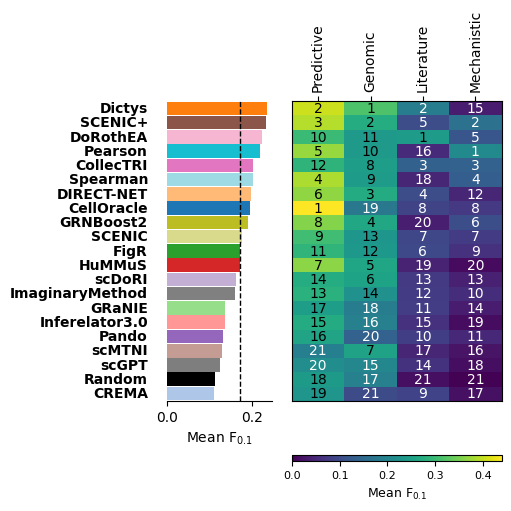

In [13]:
gt.pl.ranking(res, level="class", figsize=(5, 5))

This heatmap color indicates mean $F_{0.1}$ scores, and the numbers indicate the ranking inside each metric class (lower is better).

By default, all four metric classes (Predictive, Genomic, Literature and Mechanistic) are weighted equally when computing the overall mean $F_{0.1}$ that orders the methods. You can change this by passing a `metric_weights` dictionary, for example to give more importance to genomic evidence:

```python
gt.pl.ranking(res, level='class', metric_weights=dict(predictive=1, genomic=2, literature=1, mechanistic=1))
```

Any metric class omitted from the dictionary is given a weight of 0, so it is effectively dropped from the ranking. If instead you want to focus on particular tasks or databases, you can subset `res` before plotting.

If you need the exact mean $F_{0.1}$ values behind the ordering, you can compute them directly with `gt.tl.ranking`, which accepts the same `metric_weights` argument and returns them as a dataframe sorted from best to worst:

In [14]:
rnk = gt.tl.ranking(res)
rnk.head()

,mean_f01
name,
Dictys,0.234817
SCENIC+,0.232779
DoRothEA,0.223942
Pearson,0.218193
CollecTRI,0.201690


Alternatively, we can visualize the results at finer resolution, grouped by individual evaluation task, to see which specific databases or subtasks drive the differences between methods:

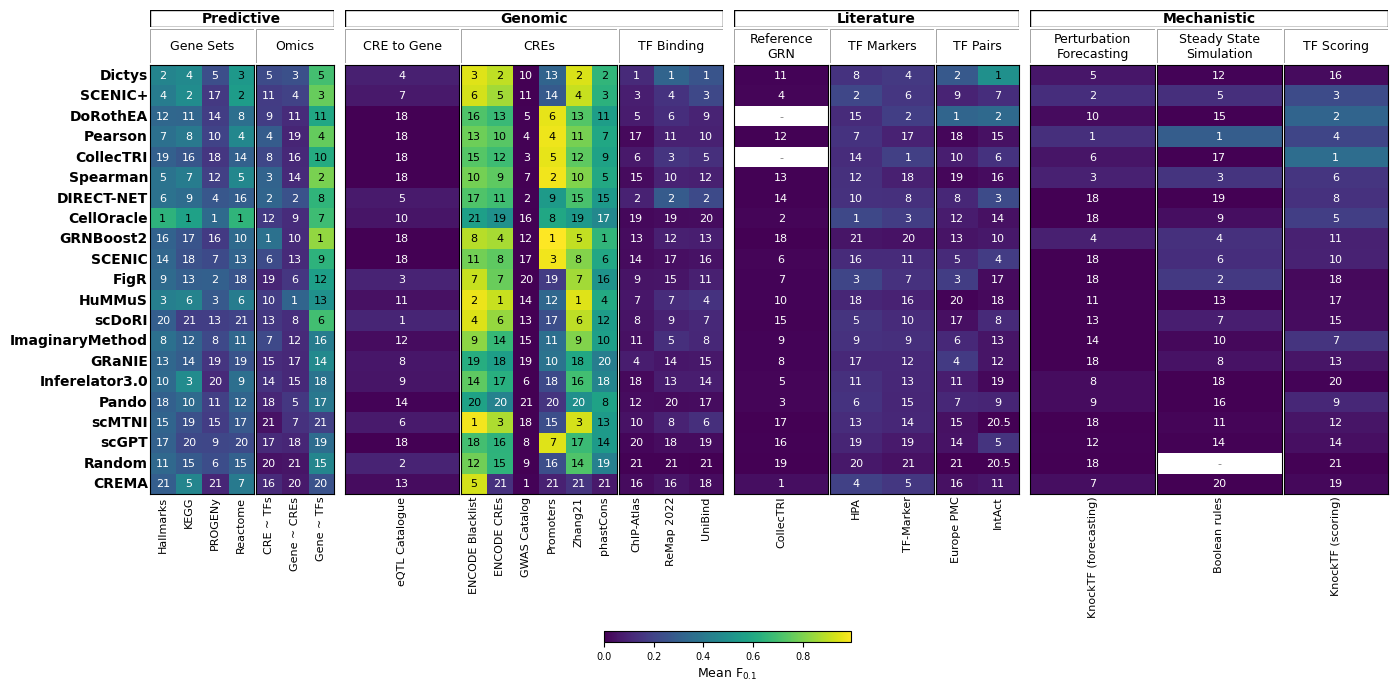

In [15]:
gt.pl.ranking(res, level="task")

In this case, ImaginaryMethod does not manage to outperform the top-performing methods in the benchmark. To understand where a method falls short, inspecting the task-level plot can help identify which metric categories drive its ranking.